In [12]:
import pandas as pd
import re
import os
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from pyteomics import mgf, mass
from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_rt_predictions,
    safe_obtain_ccs_predictions,
)
from seq_utils.peptide import switch_random_il, get_proforma_bracketed
import metrics.metrics as M

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList
from seq_utils.peptide import has_il_outside_brackets

%matplotlib inline

In [13]:
# Load MaxQuant search results
df = pd.read_csv("../temp_data/input_file.txt", sep="\t")
df = df[df["Sequence"].str.len() < 30]

modification_dict_koina = {"(ox)": "UNIMOD:35", "(ac)": "UNIMOD:1", "(oxidation (m))": "UNIMOD:35", "(acetyl (protein n-term))": "UNIMOD:1"}
df["proforma_koina"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_koina,
)

modification_dict_deeplc = {"(ox)": "Oxidation", "(ac)": "Acetyl", "(oxidation (m))": "Oxidation", "(acetyl (protein n-term))": "Acetyl"}
df["proforma_deeplc"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_deeplc,
)

merged_df = df.merge(
    df.groupby("proforma_deeplc")["Calibrated retention time"].mean(),
    on="proforma_deeplc", how="left", suffixes=('', '_mean')
)
merged_df = merged_df.drop_duplicates(subset="proforma_deeplc", keep="first")

df_intensity = df[~df["proforma_koina"].str.contains(r"\[", na=False)].copy()
df_intensity = df_intensity[~np.isnan(df_intensity["MS/MS scan number"])]
df_intensity = df_intensity[df_intensity["Charge"] == 2]

peptides = np.array(df_intensity["proforma_koina"])
charges = np.array(df_intensity["Charge"])
peptides_switched = np.array([switch_random_il(p) for p in peptides])

print(f"Full dataset (for RT): {len(merged_df)} unique peptides")
print(f"Fragment intensity dataset (unmodified, charge 2): {len(df_intensity)} peptides")

Full dataset (for RT): 44227 unique peptides
Fragment intensity dataset (unmodified, charge 2): 121526 peptides


In [14]:
# Load MGF files
def parse_mgf(file_path):
    filename = os.path.splitext(os.path.basename(file_path))[0]
    spectra = {}
    with mgf.read(file_path) as reader:
        for spectrum in tqdm(reader):
            scan_str = spectrum.get("params", {})["title"].split(" scan=")[1].replace("\"", "")
            scan_number = int(scan_str) if scan_str else 0
            spectra[scan_number] = {
                'm/z array': spectrum.get('m/z array', []),
                'intensity array': spectrum.get('intensity array', [])
            }
    return {filename: spectra}

files = [
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_03.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_03.mgf",
]

mgf_dict = {}
for f in files:
    mgf_dict.update(parse_mgf(f))

100%|██████████| 118174/118174 [00:13<00:00, 8602.77it/s] 


In [15]:
# Load or generate fragment intensity predictions
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions_puyvelde.csv"
peptides_predictions_f = "../temp_data/peptides_predictions_puyvelde.csv"

def safe_obtain_predictions(peptides_batch, switched, charges, max_retries=3):
    for attempt in range(max_retries):
        try:
            return obtain_predictions_pairs(peptides_batch, switched=switched,
                                            model="AlphaPeptDeep_ms2_generic",
                                            charges=charges, collision_energies=27)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                raise RuntimeError(f"Prediction failed after {max_retries} attempts.") from e

if os.path.exists(peptides_switch_predictions_f) and os.path.exists(peptides_predictions_f):
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    batch_size = 5000
    peptides_switch_predictions_list, peptides_predictions_list = [], []
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch, batch_switched = peptides[i:i+batch_size], peptides_switched[i:i+batch_size]
        batch_charges = charges[i:i+batch_size]
        peptides_switch_predictions_list.append(safe_obtain_predictions(batch_switched, True, batch_charges))
        peptides_predictions_list.append(safe_obtain_predictions(batch, False, batch_charges))

    peptides_switch_predictions = pd.concat(peptides_switch_predictions_list, ignore_index=True)
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)
    peptides_switch_predictions.to_csv(peptides_switch_predictions_f, index=False)
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

dict_predictions = dict(tuple(peptides_predictions.groupby("peptide_sequences")))
dict_predictions_switched = dict(tuple(peptides_switch_predictions.groupby("peptide_sequences")))

In [16]:
# Spectrum annotation and matching
def get_theoretical_fragments(peptide_sequence, max_charge=2):
    clean_seq = re.sub(r'\[.*?\]', '', peptide_sequence)
    fragments = []
    seq_len = len(clean_seq)
    for i in range(1, seq_len):
        for z in range(1, max_charge + 1):
            try:
                fragments.append({'ion': f"b{i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[:i], ion_type='b', charge=z)})
            except: pass
            try:
                fragments.append({'ion': f"y{seq_len-i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[i:], ion_type='y', charge=z)})
            except: pass
    return fragments

def annotate_spectrum(mz_array, intensity_array, peptide_sequence, charge, tol_ppm=20):
    mz_array, intensity_array = np.array(mz_array, dtype=np.float64), np.array(intensity_array, dtype=np.float64)
    matched, used_peaks = [], set()
    for frag in get_theoretical_fragments(peptide_sequence, max_charge=charge):
        mz_diff = np.abs((mz_array - frag['mz']) / frag['mz'] * 1e6)
        matches = np.where(mz_diff < tol_ppm)[0]
        if len(matches) > 0:
            best_idx = matches[np.argmin(mz_diff[matches])]
            if best_idx not in used_peaks:
                used_peaks.add(best_idx)
                matched.append({'ion': frag['ion'], 'charge': frag['charge'], 'intensity': intensity_array[best_idx]})
    return pd.DataFrame(matched)

dict_orig_to_swap = dict(zip(peptides, peptides_switched))
dict_il_intensity = {}
for idx, row in tqdm(df_intensity.iterrows(), total=len(df_intensity), desc="Processing"):
    mz_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]["m/z array"]
    intensity_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]['intensity array']

    df_annotation = annotate_spectrum(mz_array, intensity_array, row['proforma_koina'], row['Charge'])
    if df_annotation.empty:
        continue

    swap_sequence = dict_orig_to_swap.get(row['proforma_koina'])
    sub_df_pred = dict_predictions.get(row['proforma_koina'])
    sub_df_pred_sw = dict_predictions_switched.get(swap_sequence) if swap_sequence else None
    if sub_df_pred is None or sub_df_pred_sw is None:
        continue

    sub_df_pred = sub_df_pred.copy()
    sub_df_pred_sw = sub_df_pred_sw.copy()
    sub_df_pred[['ion', 'charge']] = sub_df_pred['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred['charge'] = sub_df_pred['charge'].astype(int)
    sub_df_pred_sw[['ion', 'charge']] = sub_df_pred_sw['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred_sw['charge'] = sub_df_pred_sw['charge'].astype(int)
    df_annotation['charge'] = df_annotation['charge'].astype(int)

    merged = pd.merge(df_annotation, sub_df_pred, on=['ion', 'charge'], how='inner')
    merged_all = pd.merge(merged, sub_df_pred_sw, on=['ion', 'charge'], how='inner').drop_duplicates()

    if merged_all.empty or max(merged_all["intensity"].values) == 0:
        continue

    max_int = max(merged_all["intensity"].values)
    dict_il_intensity[row['proforma_koina']] = {
        "intensity_obs_norm": merged_all["intensity"].values / max_int,
        "intensities_orig": merged_all["intensities_x"].values,
        "intensities_swapped": merged_all["intensities_y"].values,
        "mz_orig": merged_all["mz_x"].values,
    }

Processing: 100%|██████████| 121526/121526 [08:24<00:00, 240.92it/s]


In [17]:
# Score all peptides with fragment intensity metrics
metric_keys = [
    "x_corr",
    "pearson_correlation",
    "spearman_correlation",
    "kendall_tau",
    "cosine_similarity",
    "spectral_angle",
    "weighted_dot_product",
    "fit",
    "ruzicka_similarity_1",
    "ruzicka_similarity_2",
    "mse",
    "canberra_distance",
    "wasserstein",
    "bray_curtis",
    "mutual_information",
]

scored_dict_seqs = {}
for seq, frag in tqdm(dict_il_intensity.items()):
    score_dict = {}
    inp_base = {"mz1": frag["mz_orig"], "mz2": frag["mz_orig"],
                "diagnostic_mz": np.array([]), "mz": max(frag["mz_orig"])}

    for key in metric_keys:
        try:
            score = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_orig"], **inp_base)
        except: score = np.nan
        try:
            score_sw = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_swapped"], **inp_base)
        except: score_sw = np.nan
        score_dict[f"{key}|orig"], score_dict[f"{key}|swapped"] = score, score_sw

    scored_dict_seqs[seq] = score_dict

scored_df_seqs = pd.DataFrame(scored_dict_seqs).T

# Free MGF memory
del mgf_dict

100%|██████████| 30558/30558 [01:29<00:00, 340.71it/s]


In [18]:
# DeepLC RT predictions
df_train = merged_df.sample(frac=0.1, random_state=42)
df_eval = merged_df.drop(df_train.index).copy()

psm_list_train = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_train.iterrows()
])

rt_swap_dict = {}
for idx, row in df_eval.iterrows():
    rt_swap_dict[row["proforma_deeplc"]] = switch_random_il(row["proforma_deeplc"])

psm_list_eval = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])
psm_list_eval_swapped = PSMList(psm_list=[
    PSM(peptidoform=rt_swap_dict[row["proforma_deeplc"]], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])

dlc = DeepLC(deeplc_retrain=False, n_epochs=20)
dlc.calibrate_preds(psm_list_train)
preds = dlc.make_preds(psm_list=psm_list_eval)
preds_swapped = dlc.make_preds(psm_list=psm_list_eval_swapped)

df_eval["predicted_rt"] = preds
df_eval["predicted_rt_swapped"] = preds_swapped
print(f"RT predictions complete: {len(df_eval)} peptides")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
RT predictions complete: 39804 peptides


In [19]:
# Build overlap set: I/L peptides with both fragment intensity scores and RT predictions
koina_to_deeplc = dict(zip(df_intensity["proforma_koina"], df_intensity["proforma_deeplc"]))

# RT prediction lookup
rt_pred_lookup = {}
for idx, row in df_eval.iterrows():
    rt_pred_lookup[row["proforma_deeplc"]] = {
        "pred_rt": row["predicted_rt"],
        "pred_rt_sw": row["predicted_rt_swapped"],
        "obs_rt": row["Calibrated retention time_mean"],
    }

# Determine vote direction for each metric from the data
# If raw ratio > 0.5: positive diff = original is correct
# If raw ratio < 0.5: negative diff = original is correct
metric_sign = {}
for key in metric_keys:
    diff = scored_df_seqs[f"{key}|orig"] - scored_df_seqs[f"{key}|swapped"]
    pos, neg = (diff > 0).sum(), (diff < 0).sum()
    metric_sign[key] = 1 if pos >= neg else -1

# Build per-peptide vote matrix
votes = []
for seq in scored_df_seqs.index:
    if not has_il_outside_brackets(seq):
        continue
    deeplc_seq = koina_to_deeplc.get(seq)
    if deeplc_seq is None or deeplc_seq not in rt_pred_lookup:
        continue

    rt_info = rt_pred_lookup[deeplc_seq]
    diff_orig = abs(rt_info["pred_rt"] - rt_info["obs_rt"])
    diff_swap = abs(rt_info["pred_rt_sw"] - rt_info["obs_rt"])

    row = {"sequence": seq}

    # RT vote
    if diff_orig < diff_swap:
        row["rt"] = 1
    elif diff_orig > diff_swap:
        row["rt"] = -1
    else:
        row["rt"] = 0

    # Fragment intensity votes (direction-corrected)
    for key in metric_keys:
        orig_score = scored_df_seqs.at[seq, f"{key}|orig"]
        swap_score = scored_df_seqs.at[seq, f"{key}|swapped"]
        if pd.isna(orig_score) or pd.isna(swap_score) or orig_score == swap_score:
            row[key] = 0
        elif orig_score > swap_score:
            row[key] = metric_sign[key]
        else:
            row[key] = -metric_sign[key]

    votes.append(row)

vote_df = pd.DataFrame(votes)
print(f"Overlap set: {len(vote_df)} I/L peptides with both fragment intensity and RT")

Overlap set: 24292 I/L peptides with both fragment intensity and RT


In [20]:
from itertools import combinations

# Helper to compute ratio correct from a vote series
def ratio_correct_from_votes(v):
    correct = (v > 0).sum()
    incorrect = (v < 0).sum()
    total = correct + incorrect
    ratio = correct / total if total > 0 else 0.5
    return 1.0 - ratio if ratio < 0.5 else ratio

# Exhaustive search for the best-synergizing trio of fragment intensity metrics
# C(15,3) = 455 combinations
vote_arrays = {key: vote_df[key].values for key in metric_keys}

best_trio_score = 0
best_trio = None
trio_results = []

for combo in combinations(metric_keys, 3):
    vote_sum = vote_arrays[combo[0]] + vote_arrays[combo[1]] + vote_arrays[combo[2]]
    votes_sign = np.sign(vote_sum)
    score = ratio_correct_from_votes(pd.Series(votes_sign))
    trio_results.append((combo, score))
    if score > best_trio_score:
        best_trio_score = score
        best_trio = combo

# Also search best trio + RT
best_trio_rt_score = 0
best_trio_rt = None

for combo in combinations(metric_keys, 3):
    vote_sum = vote_arrays[combo[0]] + vote_arrays[combo[1]] + vote_arrays[combo[2]] + vote_df["rt"].values
    votes_sign = np.where(vote_sum != 0, np.sign(vote_sum), vote_df["rt"].values)
    score = ratio_correct_from_votes(pd.Series(votes_sign))
    if score > best_trio_rt_score:
        best_trio_rt_score = score
        best_trio_rt = combo

# Show top 10 trios
trio_results.sort(key=lambda x: x[1], reverse=True)
print("Top 10 synergistic trios (fragment intensity only):")
for combo, score in trio_results[:10]:
    marker = " <-- best" if combo == best_trio else ""
    print(f"  {score:.4f}  {', '.join(combo)}{marker}")

print(f"\nBest trio: {best_trio} -> {best_trio_score:.4f}")
print(f"Best trio + RT: {best_trio_rt} -> {best_trio_rt_score:.4f}")

# Compute all combinations using the best synergistic trio
top_metrics = list(best_trio)

# Combination 1: Best individual intensity + RT (equal weight, RT tiebreaker)
vote_sum = vote_df["weighted_dot_product"] + vote_df["rt"]
vote_df["best_int+rt"] = np.where(vote_sum != 0, np.sign(vote_sum), vote_df["rt"])

# Combination 2: Best synergistic trio (majority vote)
vote_df["best_trio"] = np.sign(vote_df[top_metrics].sum(axis=1))

# Combination 3: Best synergistic trio + RT (majority vote, RT tiebreaker)
best_trio_rt_metrics = list(best_trio_rt)
vote_sum = vote_df[best_trio_rt_metrics + ["rt"]].sum(axis=1)
vote_df["best_trio+rt"] = np.where(vote_sum != 0, np.sign(vote_sum), vote_df["rt"])

# Compute ratio correct for all metrics on the overlap set
all_ratios = {}
for key in metric_keys:
    all_ratios[key] = ratio_correct_from_votes(vote_df[key])

all_ratios["retention_time"] = ratio_correct_from_votes(vote_df["rt"])
all_ratios["best_int+rt"] = ratio_correct_from_votes(vote_df["best_int+rt"])
all_ratios["best_trio"] = ratio_correct_from_votes(vote_df["best_trio"])
all_ratios["best_trio+rt"] = ratio_correct_from_votes(vote_df["best_trio+rt"])

print(f"\nRatio correct on overlap set ({len(vote_df)} peptides):")
print("=" * 55)
for k, v in sorted(all_ratios.items(), key=lambda x: x[1], reverse=True):
    tag = ""
    if k == "best_trio":
        tag = f" ({', '.join(top_metrics)})"
    elif k == "best_trio+rt":
        tag = f" ({', '.join(best_trio_rt_metrics)} + RT)"
    elif k == "best_int+rt":
        tag = " (weighted_dot_product + RT)"
    elif k == "retention_time":
        tag = " (RT)"
    print(f"  {k:35s}: {v:.4f}{tag}")

Top 10 synergistic trios (fragment intensity only):
  0.6313  kendall_tau, ruzicka_similarity_2, mutual_information <-- best
  0.6310  kendall_tau, weighted_dot_product, ruzicka_similarity_1
  0.6309  kendall_tau, ruzicka_similarity_1, mutual_information
  0.6309  kendall_tau, weighted_dot_product, mutual_information
  0.6299  weighted_dot_product, ruzicka_similarity_1, mutual_information
  0.6295  kendall_tau, weighted_dot_product, ruzicka_similarity_2
  0.6285  pearson_correlation, kendall_tau, ruzicka_similarity_1
  0.6280  pearson_correlation, kendall_tau, weighted_dot_product
  0.6279  spearman_correlation, weighted_dot_product, ruzicka_similarity_1
  0.6270  pearson_correlation, kendall_tau, ruzicka_similarity_2

Best trio: ('kendall_tau', 'ruzicka_similarity_2', 'mutual_information') -> 0.6313
Best trio + RT: ('weighted_dot_product', 'ruzicka_similarity_1', 'mutual_information') -> 0.6584

Ratio correct on overlap set (24292 peptides):
  best_trio+rt                       : 0.65

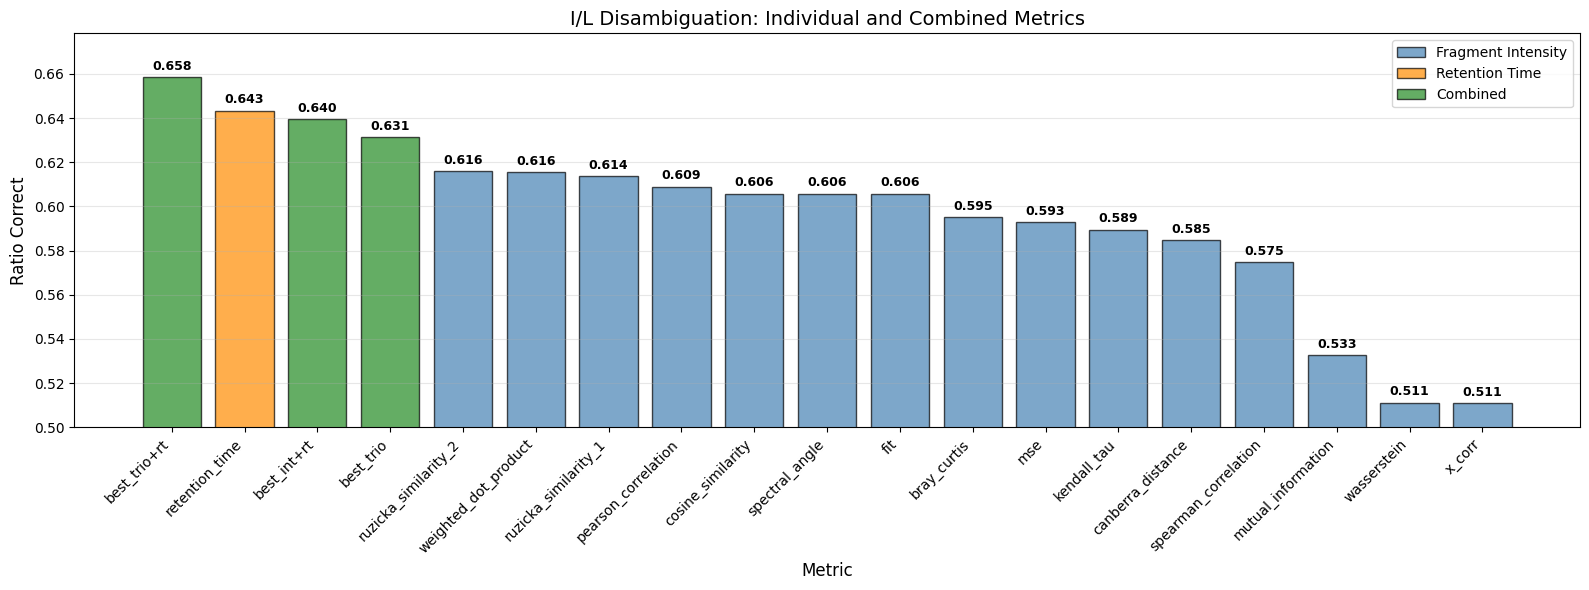

In [24]:
# Bar chart: individual and combined metrics
all_sorted = sorted(all_ratios.keys(), key=lambda x: all_ratios[x], reverse=True)
all_values = [all_ratios[m] for m in all_sorted]

combined_keys = {"best_int+rt", "best_trio", "best_trio+rt"}
colors = []
for m in all_sorted:
    if m == "retention_time":
        colors.append("darkorange")
    elif m in combined_keys:
        colors.append("forestgreen")
    else:
        colors.append("steelblue")

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(range(len(all_sorted)), all_values, color=colors, edgecolor='black', alpha=0.7)

for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.7, label='Fragment Intensity'),
    Patch(facecolor='darkorange', edgecolor='black', alpha=0.7, label='Retention Time'),
    Patch(facecolor='forestgreen', edgecolor='black', alpha=0.7, label='Combined'),
    #plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Random chance (0.5)')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xticks(range(len(all_sorted)))
ax.set_xticklabels(all_sorted, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Ratio Correct', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('I/L Disambiguation: Individual and Combined Metrics', fontsize=14)
ax.set_ylim([0.5, max(all_values) + 0.02])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../temp_data/figure5_combined_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Agreement analysis: how often do the best trio metrics agree with RT?
best_metric = top_metrics[0]
agree = ((vote_df[best_metric] > 0) & (vote_df["rt"] > 0)) | \
        ((vote_df[best_metric] < 0) & (vote_df["rt"] < 0))
disagree = ((vote_df[best_metric] > 0) & (vote_df["rt"] < 0)) | \
           ((vote_df[best_metric] < 0) & (vote_df["rt"] > 0))

n_agree = agree.sum()
n_disagree = disagree.sum()
n_either_tied = len(vote_df) - n_agree - n_disagree

agree_correct = (vote_df.loc[agree, best_metric] > 0).sum()
disagree_rt_correct = (vote_df.loc[disagree, "rt"] > 0).sum()

print(f"Agreement analysis ({best_metric} vs RT):")
print(f"  Agree:    {n_agree:6d} ({n_agree/len(vote_df)*100:.1f}%) - ratio correct: {agree_correct/n_agree:.4f}")
print(f"  Disagree: {n_disagree:6d} ({n_disagree/len(vote_df)*100:.1f}%) - RT ratio correct: {disagree_rt_correct/n_disagree:.4f}")
print(f"  Tied:     {n_either_tied:6d} ({n_either_tied/len(vote_df)*100:.1f}%)")

# Pairwise agreement between the best trio metrics
print(f"\nPairwise agreement within best trio ({', '.join(top_metrics)}):")
for m1, m2 in combinations(top_metrics, 2):
    agree_pair = ((vote_df[m1] > 0) & (vote_df[m2] > 0)) | ((vote_df[m1] < 0) & (vote_df[m2] < 0))
    disagree_pair = ((vote_df[m1] > 0) & (vote_df[m2] < 0)) | ((vote_df[m1] < 0) & (vote_df[m2] > 0))
    pct_agree = agree_pair.sum() / (agree_pair.sum() + disagree_pair.sum()) * 100
    print(f"  {m1} vs {m2}: {pct_agree:.1f}% agreement")

Agreement analysis (kendall_tau vs RT):
  Agree:      7474 (30.8%) - ratio correct: 0.7172
  Disagree:   6395 (26.3%) - RT ratio correct: 0.5603
  Tied:      10423 (42.9%)

Pairwise agreement within best trio (kendall_tau, ruzicka_similarity_2, mutual_information):
  kendall_tau vs ruzicka_similarity_2: 66.3% agreement
  kendall_tau vs mutual_information: 48.0% agreement
  ruzicka_similarity_2 vs mutual_information: 40.8% agreement
